Expects .asc files.

In [50]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, CenteredNorm

import numpy as np
import os

data_dir = os.getcwd() + "/data/CL_Jan2026/"

Reading in phase data only.

In [58]:
fname = data_dir + "#4 Glass only.asc"

f = open(fname, 'r')
IntfScaleFactor, WavelengthIn, ObliquityFactor, R = None, None, None, None
img_size_x, img_size_y = None, None
hash_in, n_hashes=False, 0
phase_img = []
for i, line in enumerate(f):
    l = line.strip()
    l = l.split()

    if i == 3: 
        img_size_x = int(l[2])
        img_size_y = int(l[3])
        print("Image size: ", img_size_x, "x", img_size_y)

    if i == 7:
        IntfScaleFactor = float(l[1])
        WavelengthIn = float(l[2])
        ObliquityFactor = float(l[4])
        print("IntfScaleFactor: ", IntfScaleFactor, "WavelengthIn: ", WavelengthIn, "ObliquityFactor: ", ObliquityFactor)

    elif i==10:
        phaseres = float(l[0])
        if phaseres == 0.0:
            R = 4096
        elif phaseres == 1.0:
            R = 32768
        else:
            ValueError("Phase resolution not 0 or 1")
        print("Phase resolution: {}".format(R))

    if l[0] == '#' and hash_in:
        # 2nd hash signifies data end
        break

    if hash_in:
        data = np.asarray(l, dtype=np.float128)
        phase_img.append(data)

    if l[0] == '#' and not hash_in:
        n_hashes += 1
    
    if n_hashes == 2:
        hash_in = True


Image size:  1670 x 1701
IntfScaleFactor:  0.5 WavelengthIn:  6.328e-07 ObliquityFactor:  1.0
Phase resolution: 32768


Text(0.5, 1.0, 'Plate #4 - CL Zygo')

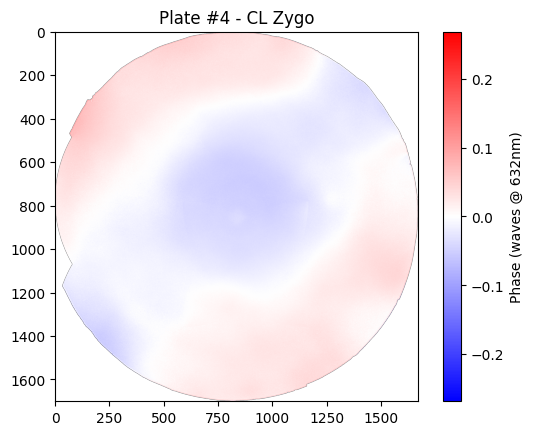

In [59]:
# phase_arr = np.asarray(phase_img)
# fx_img = np.append(phase_img[-1], 9223372036854775808)
# fx_list = phase_img[0:-1] + [fx_img]
# phase_arr = np.asarray(fx_list)
# %matplotlib qt
phase_arr = np.concatenate(phase_img)
reshaped_phase_arr = phase_arr.reshape(img_size_y, img_size_x)*(IntfScaleFactor*ObliquityFactor)/R #reshape and convert phase units to waves

# filter for pseudo-NaNs 
reshaped_phase_arr[reshaped_phase_arr == reshaped_phase_arr.max()] = np.nan

plt.imshow(reshaped_phase_arr, cmap='bwr', norm=CenteredNorm())
plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))
plt.title("Plate #4 - CL Zygo")